# 04 - Target Class Balance



## Setup



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../../data/raw data/DataCoSupplyChainDataset.csv')  
try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
class_counts = df['Late_delivery_risk'].value_counts()
class_pct = df['Late_delivery_risk'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))


Class counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Class percentages:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


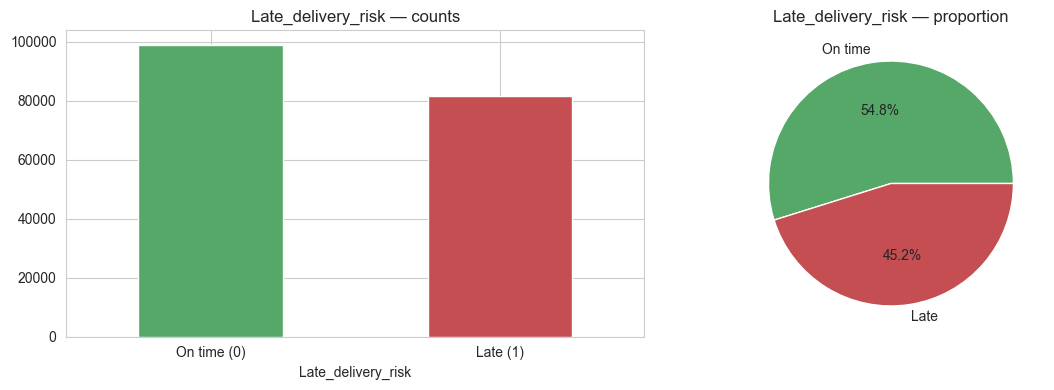

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=ax[0], color=['#55A868', '#C44E52'])
ax[0].set_title('Late_delivery_risk — counts')
ax[0].set_xticklabels(['On time (0)', 'Late (1)'], rotation=0)

ax[1].pie(class_pct, labels=['On time', 'Late'], autopct='%1.1f%%', colors=['#55A868', '#C44E52'])
ax[1].set_title('Late_delivery_risk — proportion')
plt.tight_layout()
plt.show()


**What we found:**

- **Exact split: 98,977 late (54.83%) vs. 81,542 not late (45.17%).** This matches exactly what we already found in the target variable audit (Notebook 03) 
- **This counts as close to balanced, not imbalanced.** A rough rule of thumb: anything roughly in the 40/60 to 50/50 range is considered balanced enough that severe imbalance techniques (SMOTE, heavy class weighting, undersampling) aren't strictly necessary. A ~55/45 split is well within that range.

**What this means for our evaluation strategy:**

- We do **not** need aggressive imbalance handling techniques - this removes one layer of complexity.
- **However, we still lead with Recall as our primary metric - and it's important to be precise about *why*, now that we know the classes are balanced.** The reason is **not** "because the classes are imbalanced" (they aren't, meaningfully). The reason is a **businessc ost argument**: missing a late delivery (a false negative) costs the business more than a false alarm (a false positive) - a missed at-risk shipment means no intervention happens and a real customer complaint/penalty follows, while a false alarm just means someone briefly checked an order that turned out fine. This is a *cost sensitive* framing, not an *imbalance driven* one, and it's a more precise.
- **A near balanced target also simplifies our train/test split strategy** - a plain stratified split (or a chronological split, depending on which way that decision goes) will comfortably preserve this ~55/45 ratio in both partitions without needing special balancing logic.

**`DECISION_LOG.md`:** class balance confirmed at 54.83%/45.17% on our own extracted data (not just cited from public analyses); decision to not use imbalance correction techniques, with recall prioritised for cost sensitivity reasons rather than imbalance handling reasons.
